In [1]:
library(tidyverse)
library(forecast)

#-----------------
options(
    repr.plot.width = 14,
    repr.plot.height = 9
)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.2.0
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.3     v tibble    3.3.1
v lubridate 1.9.5     v tidyr     1.3.2
v purrr     1.2.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Load and pre-process data from [Danmarks Statistik](https://www.dst.dk/da/)

In [4]:
data_full <- read.csv("data_danmarks_statistik/antal_biler.csv", na = '..')

In [5]:
glimpse(data_full)

Rows: 415
Columns: 18
$ Dato                                            <chr> "1992M01", "1992M02", ~
$ Koretojer.i.alt                                 <int> 9717, 9600, 13016, 123~
$ Personbiler.i.alt                               <int> 7147, 7314, 9897, 9717~
$ Personbiler.i.alt..sosonkorrigeret              <int> NA, NA, NA, NA, NA, NA~
$ Personbiler.i.husholdningerne                   <int> 4282, 4841, 6816, 6841~
$ Personbiler.i.husholdningerne..saesonkorrigeret <int> NA, NA, NA, NA, NA, NA~
$ Personbiler.i.erhverv                           <int> 2527, 2228, 2779, 2558~
$ Personbiler.i.erhvervene..saesonkorrigeret      <int> NA, NA, NA, NA, NA, NA~
$ Busser.i.alt                                    <int> 58, 67, 180, 115, 164,~
$ Vare..og.lastbiler.i.alt                        <int> 2317, 1899, 2285, 1749~
$ Varebiler..totalvaegt.0.2.000.kg                <int> 351, 274, 265, 226, 22~
$ Varebiler..totalvaegt.2.001.3.000.kg            <int> 1390, 1137, 1252, 1092~
$ Varebiler..total

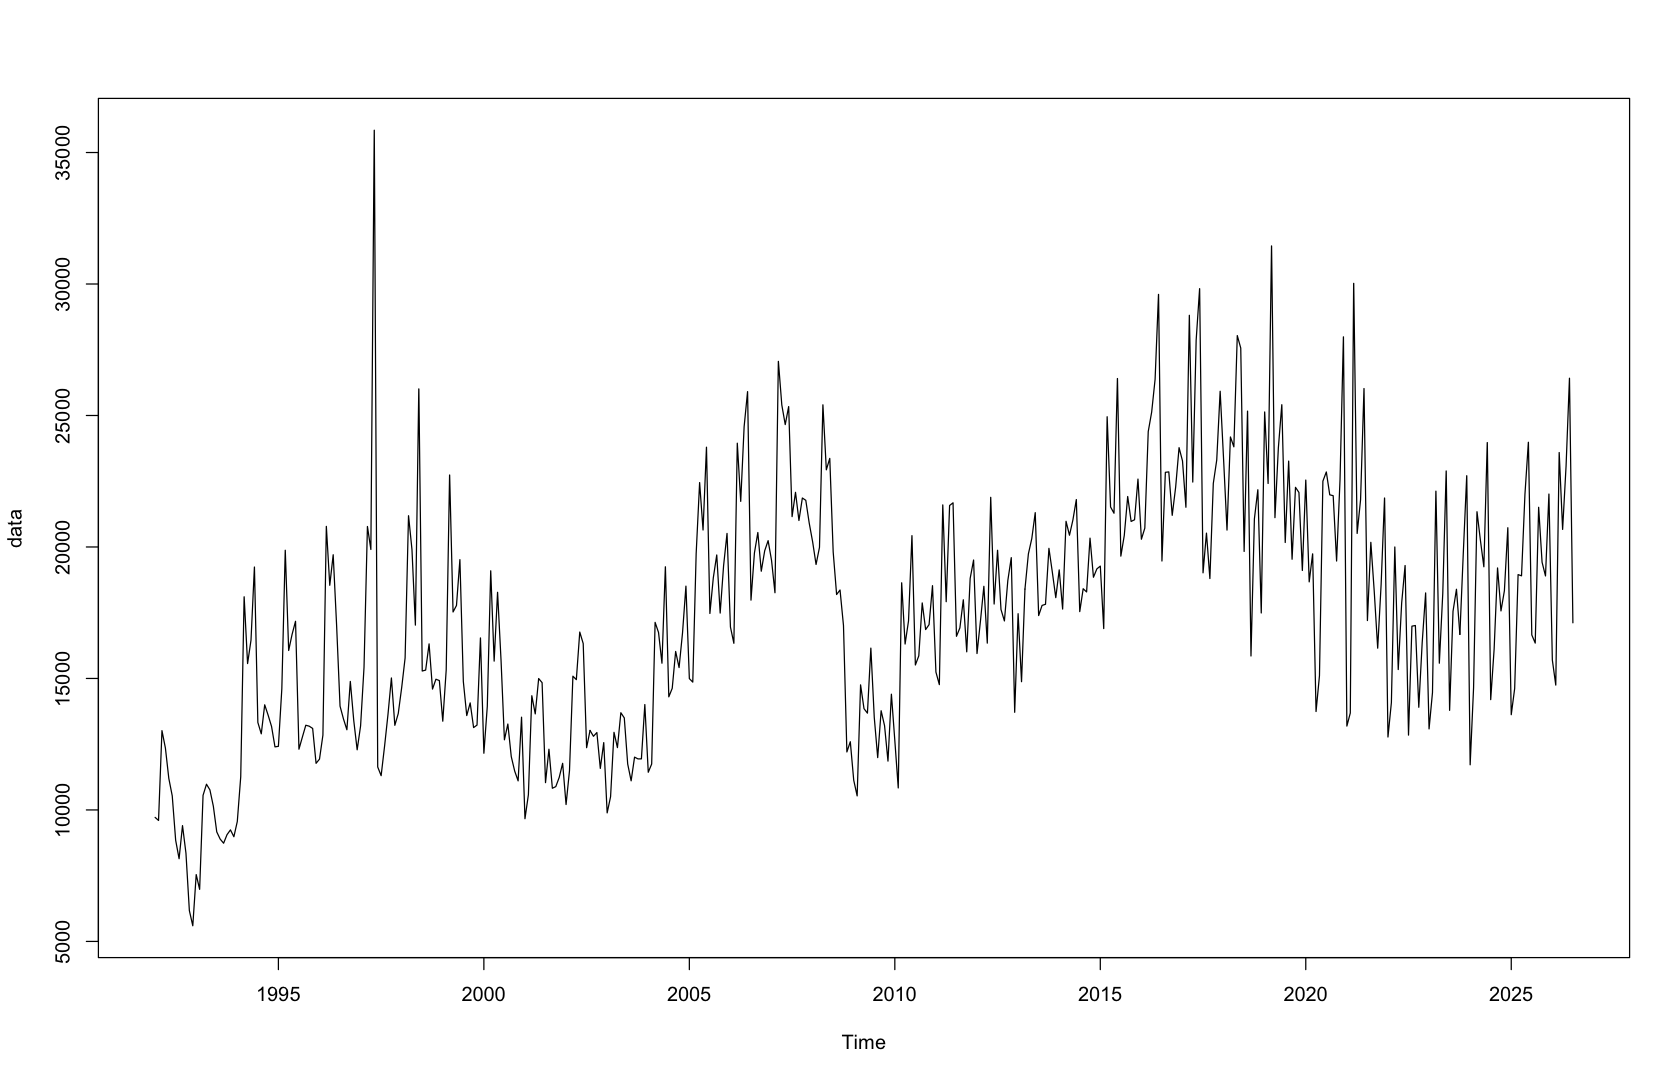

In [25]:
data <- ts(data_full$Koretojer.i.alt,
                start = c(1992, 1),
                frequency = 12,
                )

#--------------------------------------------------------
# Crop the data if needed
# data <- window(data, start = 2007)

# Log-transform if variance changes with time
# data <- log(data)

plot(data)

## Split into training and testing data (for forecasting), 95% and 5%, respectively

In [7]:
n <- length(data)
n_train <- floor(0.95 * n) # 95% of the data are training data
#---------------
data_train <- window(data, end = time(data)[n_train])
data_test  <- window(data, start = time(data)[n_train + 1])

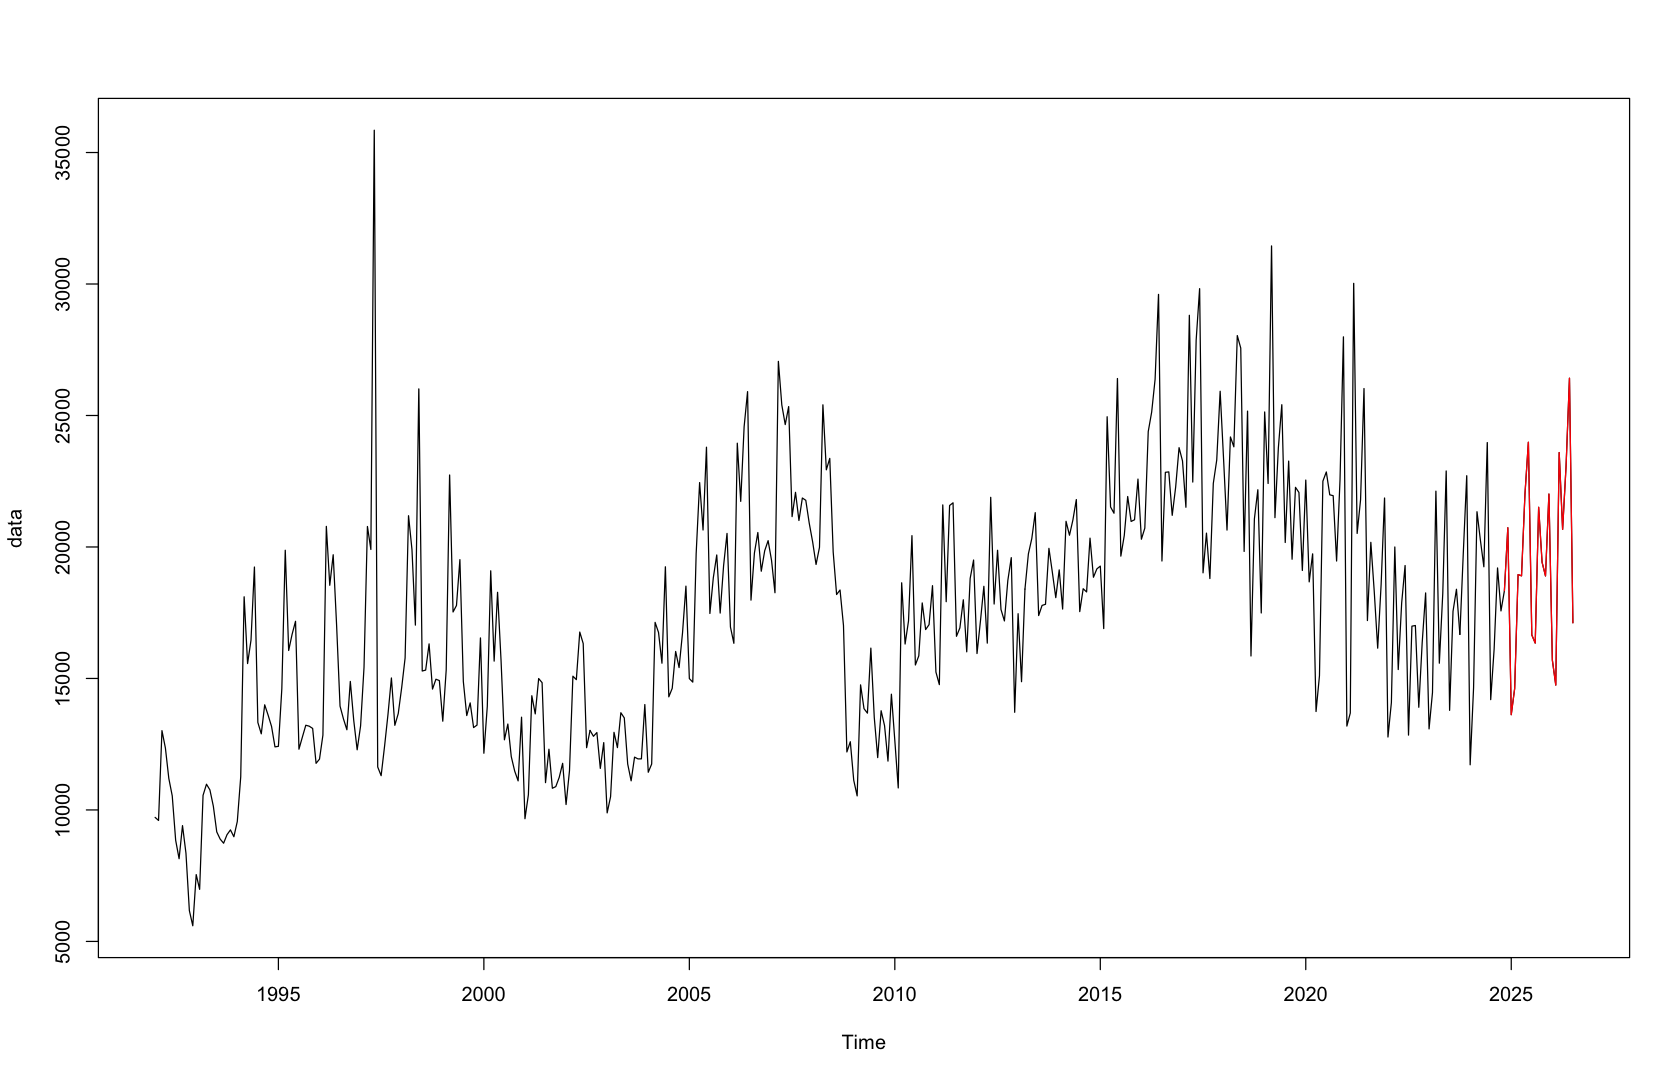

In [8]:
plot(data)
lines(data_test, col = 'red')

***

## Check ACF and PACF

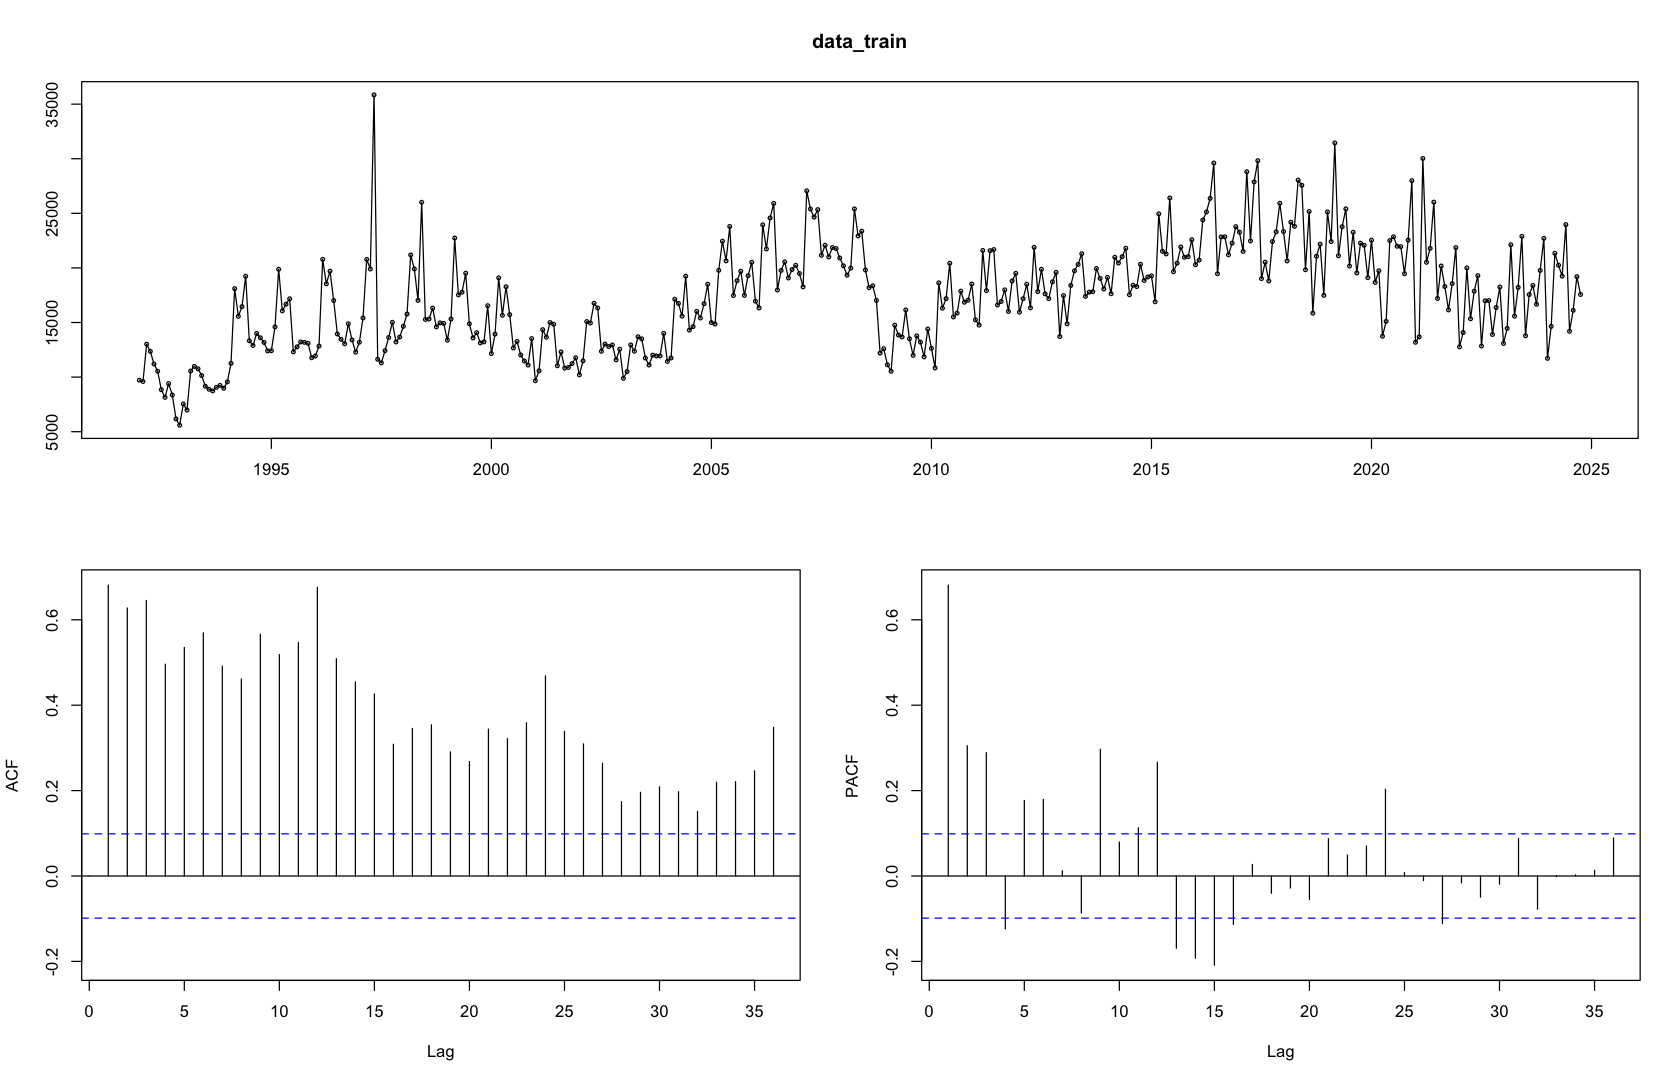

In [9]:
tsdisplay(data_train)

## Test for stationarity

In [10]:
library(tseries)

adf.test(data_train)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Warning message in adf.test(data_train):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  data_train
Dickey-Fuller = -4.1429, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary


## Test for seasonality

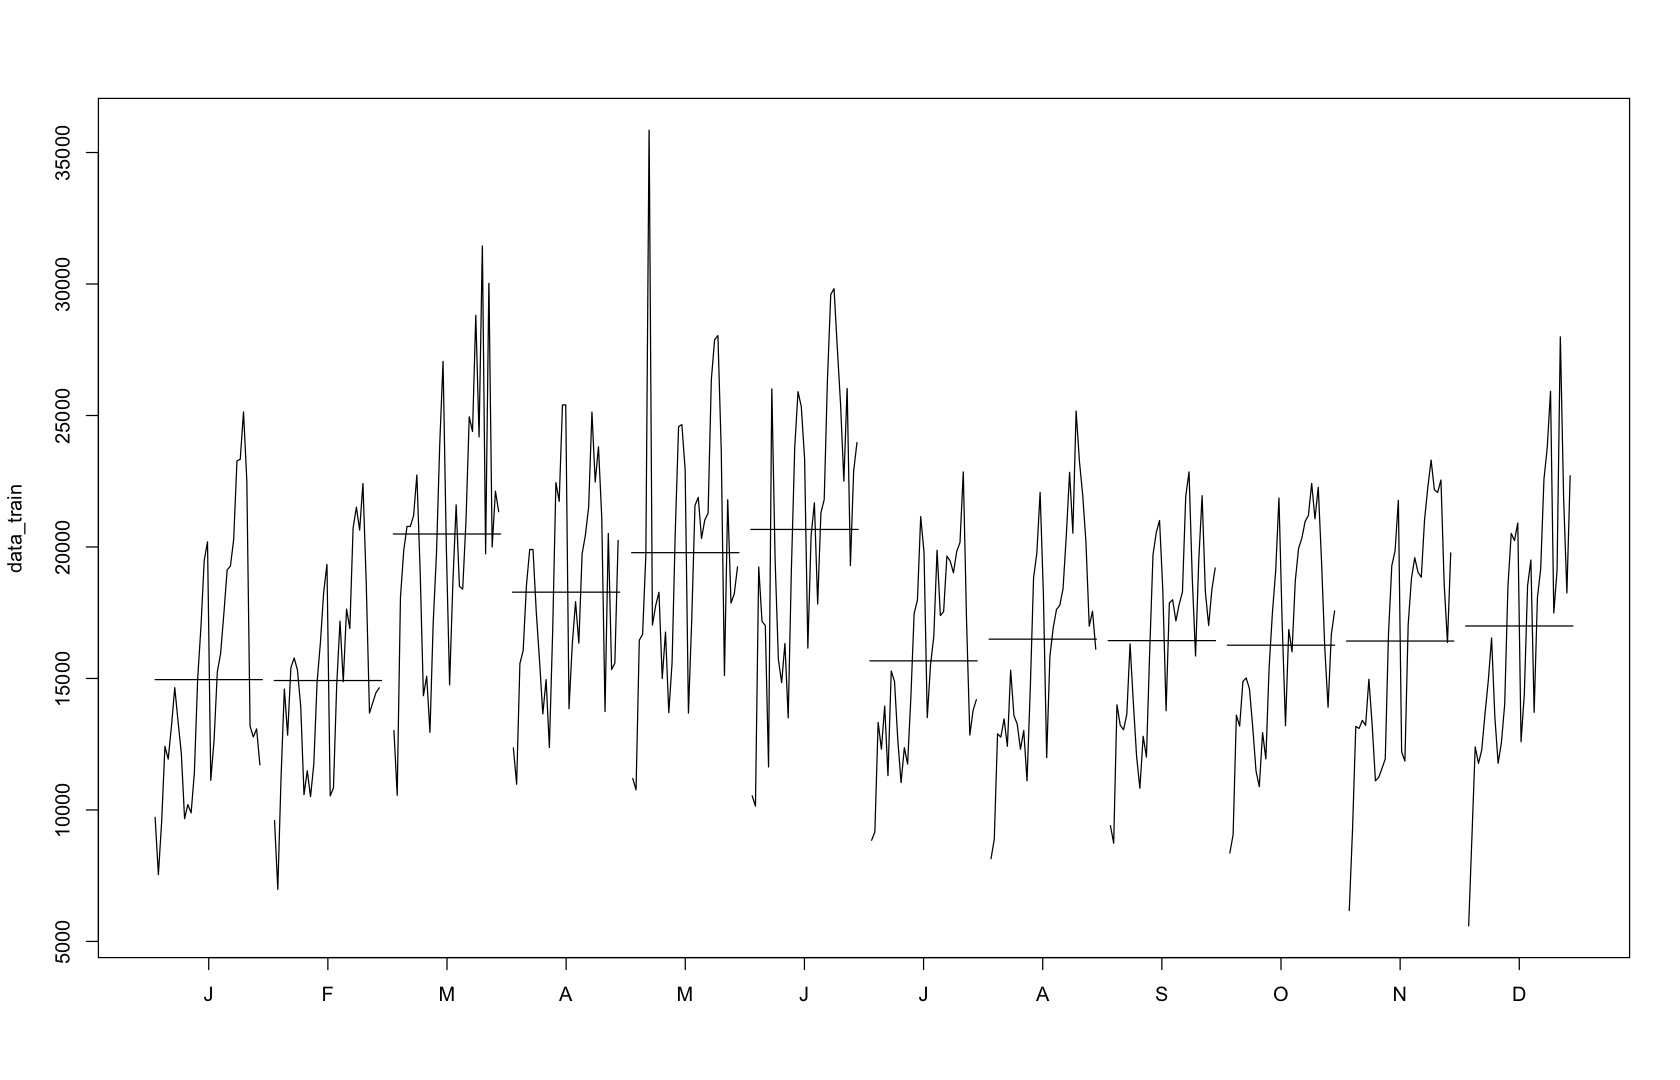

In [11]:
monthplot(data_train)

## Time series is stationary with a clear seasonal trend

***

## Seasonal-Trend decomposition using LOESS (STL)

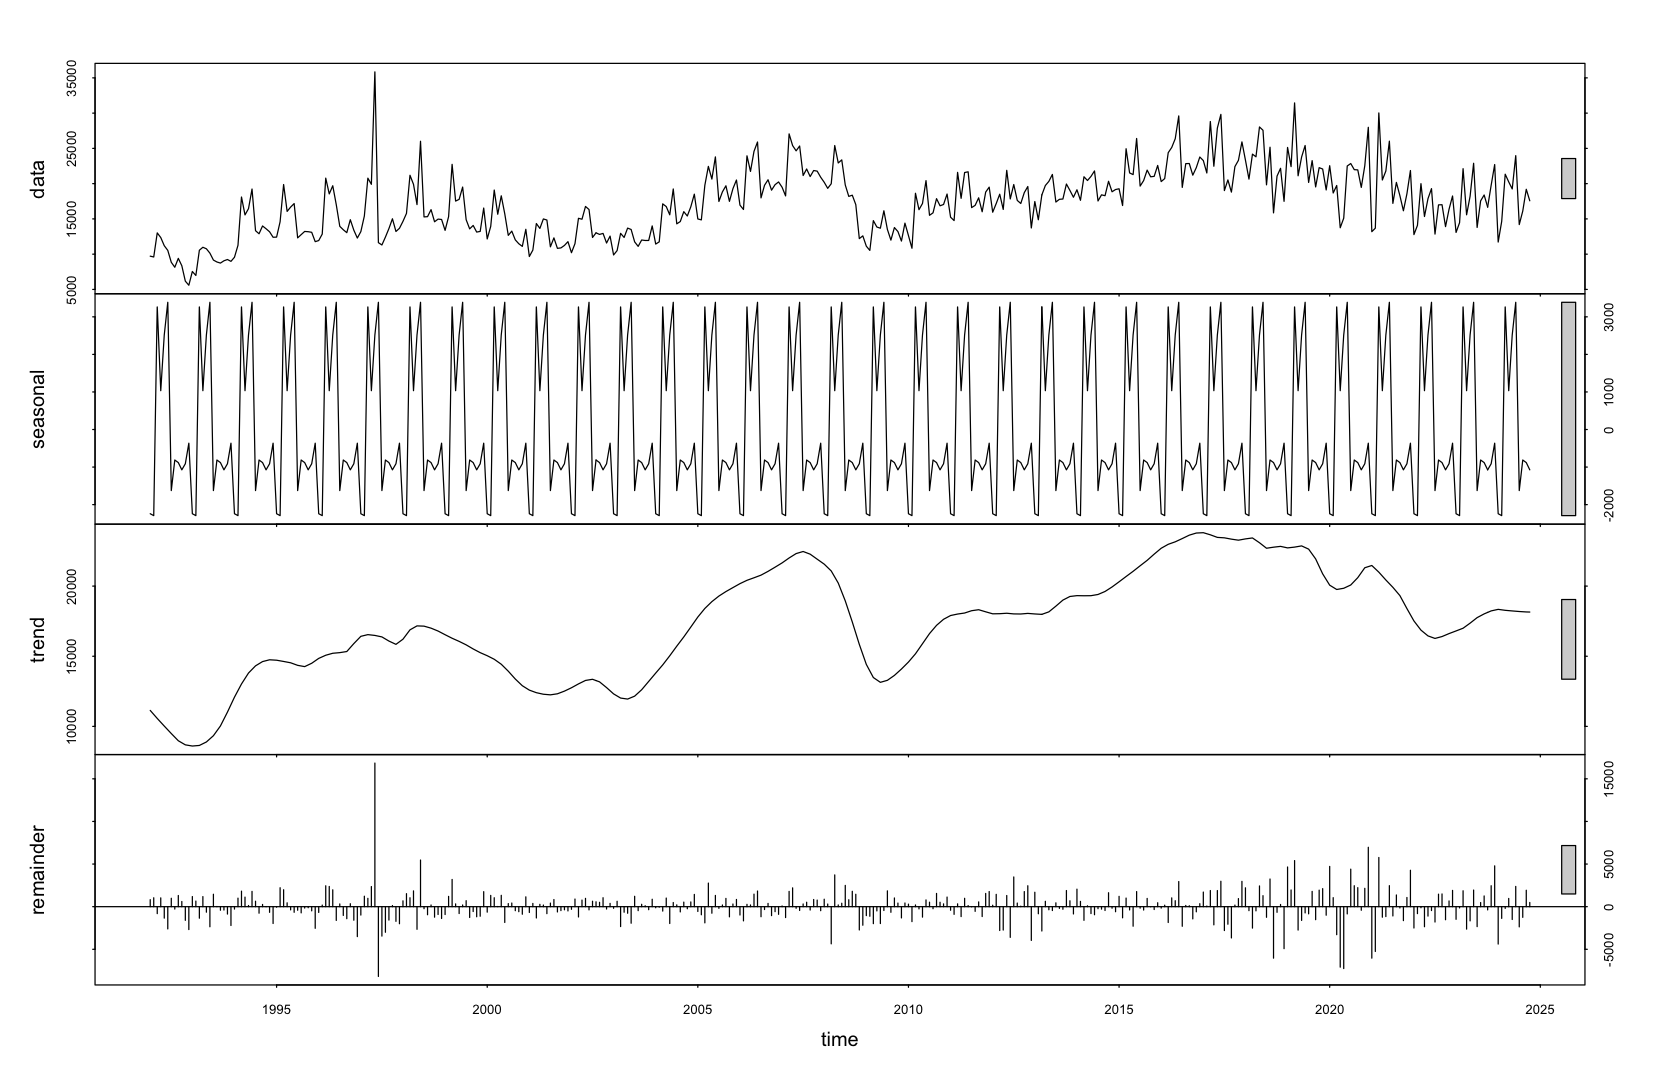

In [13]:
decomposed = stl(data_train, s.window = "periodic")

plot(decomposed)

In [14]:
forecast_stl_arima = stlf(
                        data_train, 
                        method = "arima",
                        h = n - n_train,
                        level = c(80, 95),
                        )


	Ljung-Box test

data:  Residuals from STL +  ARIMA(2,1,2)
Q* = 51.712, df = 20, p-value = 0.0001254

Model df: 4.   Total lags used: 24



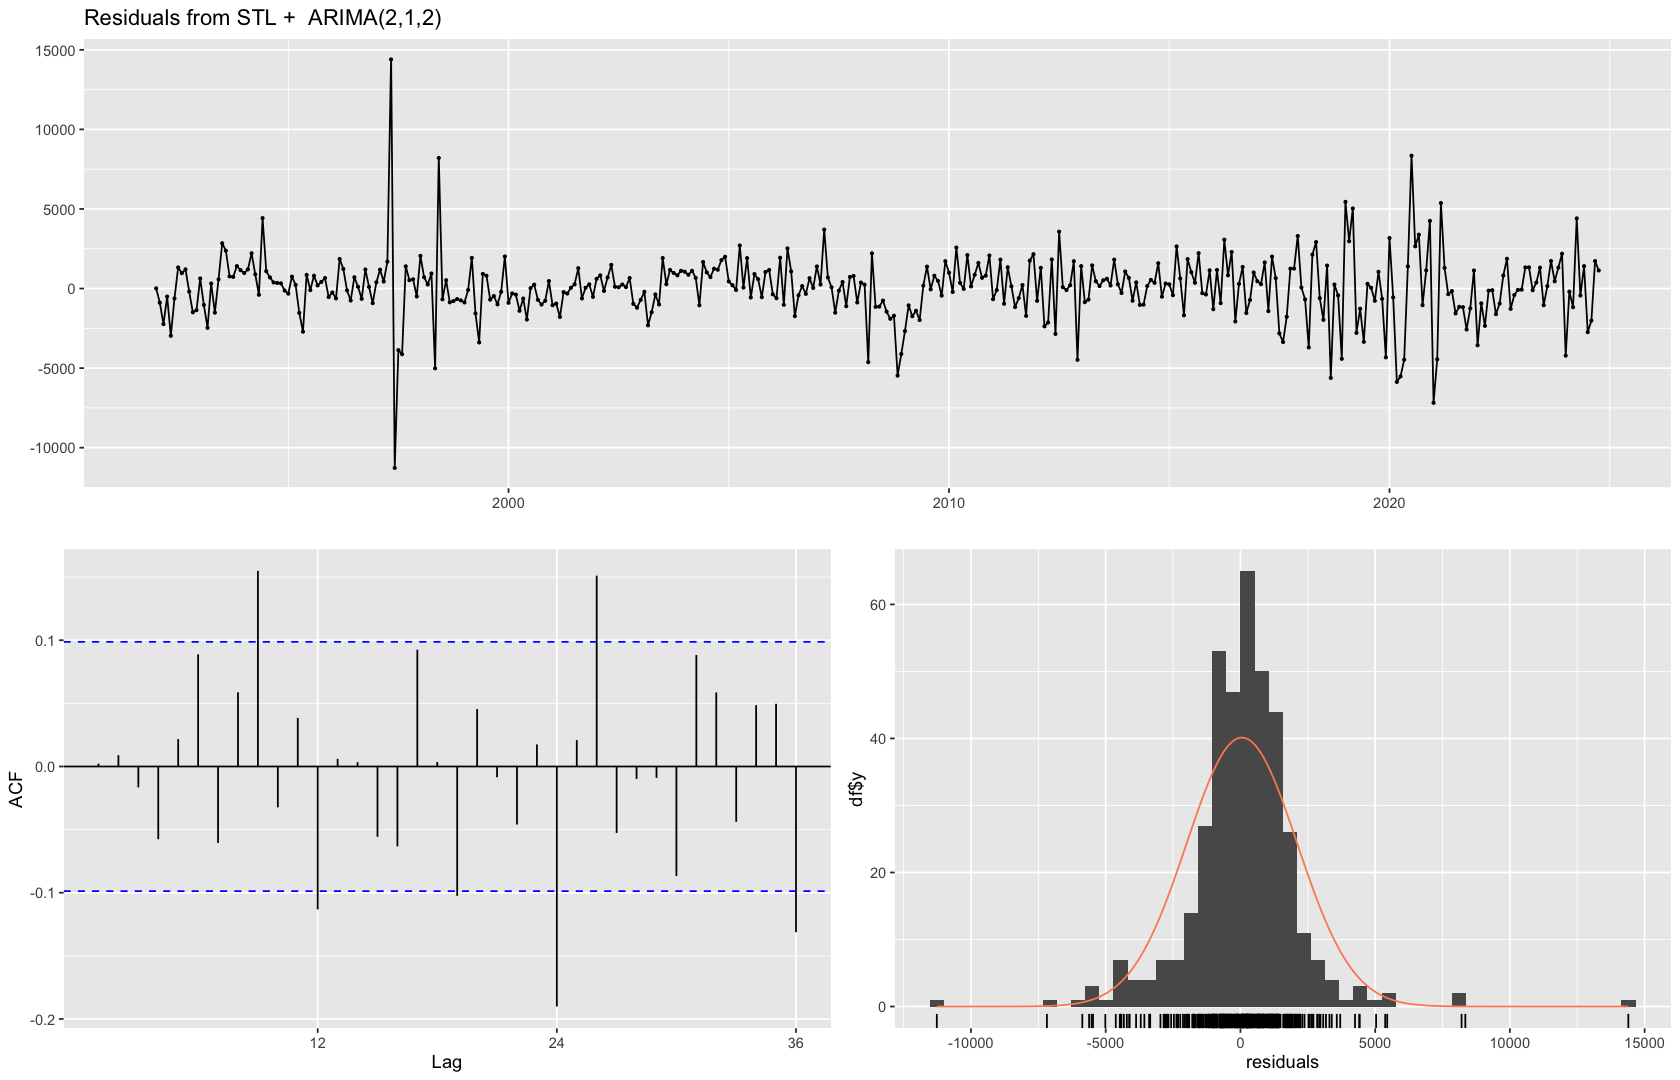

In [15]:
checkresiduals(forecast_stl_arima)

### compare raw data (black) vs. fitted model (red)

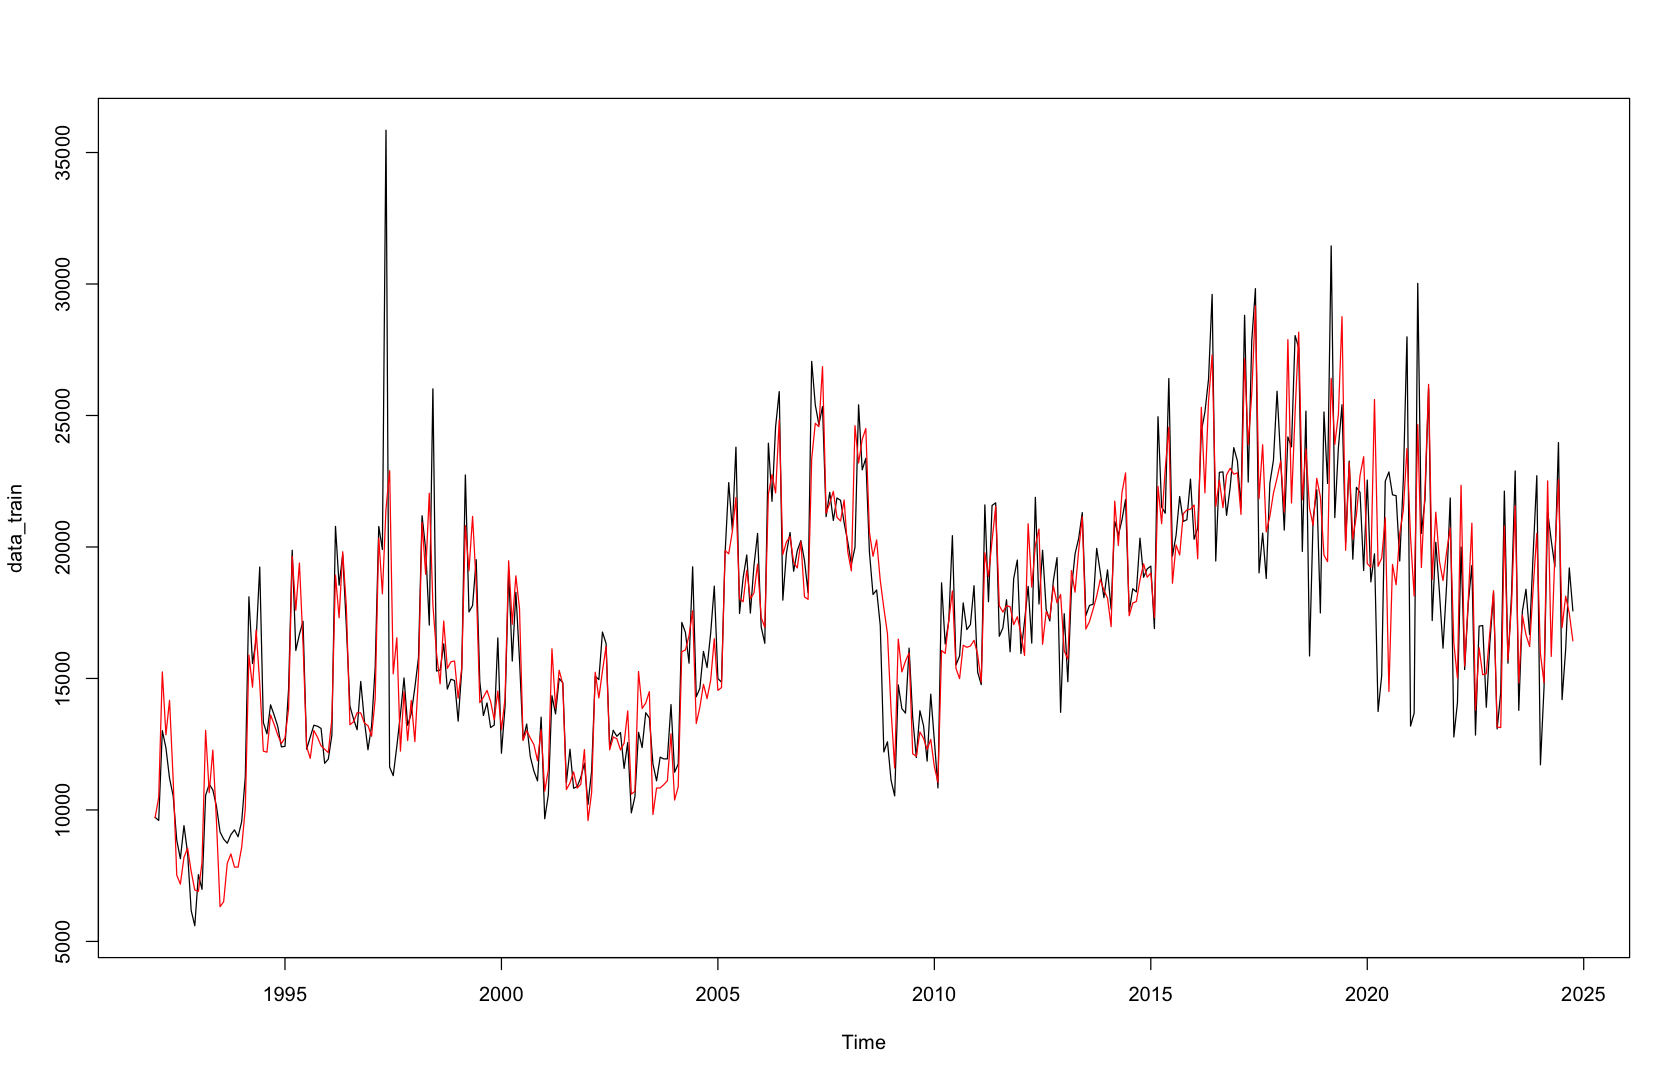

In [16]:
plot(data_train, type = "l")
lines(forecast_stl_arima$fitted, col = "red")

### forecast fitted STL-ARIMA model

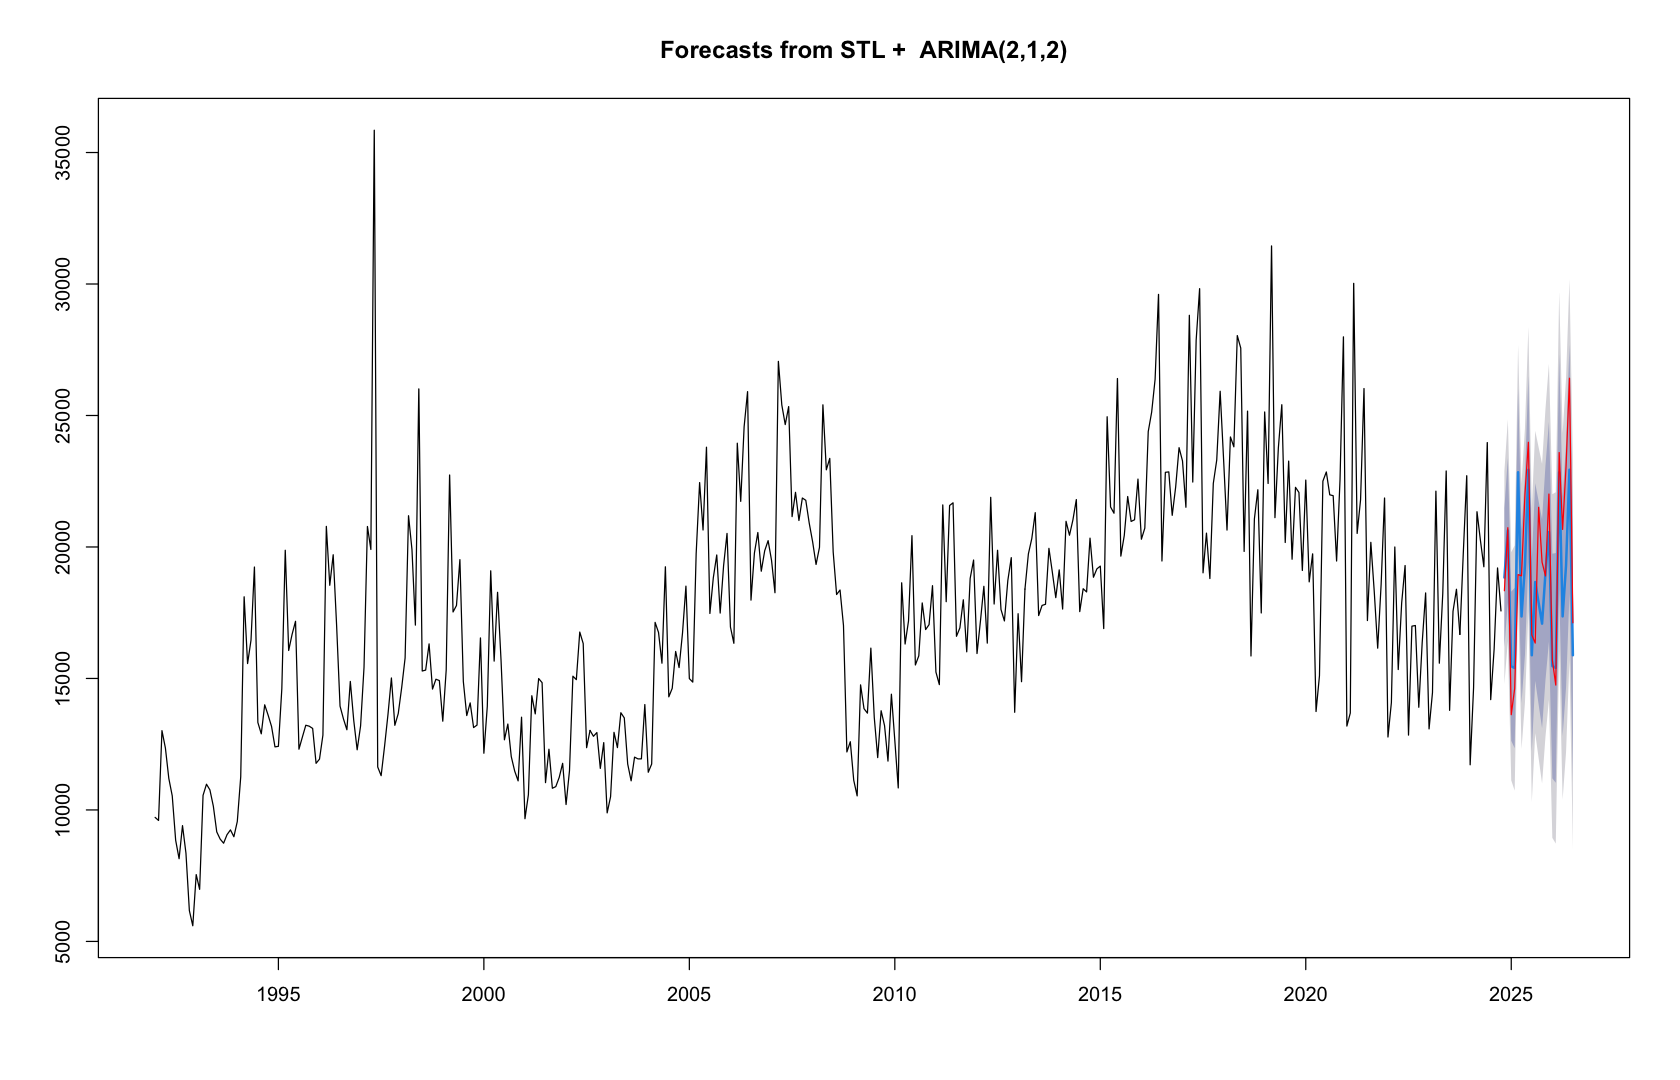

In [17]:
plot(forecast_stl_arima)
lines(data_test, col = 'red')

***

## ETS-model

In [18]:
ets_model <- ets(data_train)

ets_model

ETS(M,Ad,M) 

Call:
ets(y = data_train)

  Smoothing parameters:
    alpha = 0.435 
    beta  = 1e-04 
    gamma = 1e-04 
    phi   = 0.9767 

  Initial states:
    l = 9985.1433 
    b = 204.8864 
    s = 0.9697 0.9286 0.9266 0.9498 0.9476 0.9178
           1.2113 1.1607 1.0613 1.1929 0.8631 0.8705

  sigma:  0.1303

     AIC     AICc      BIC 
8429.162 8430.986 8500.737 


	Ljung-Box test

data:  Residuals from ETS(M,Ad,M)
Q* = 95.749, df = 24, p-value = 1.579e-10

Model df: 0.   Total lags used: 24



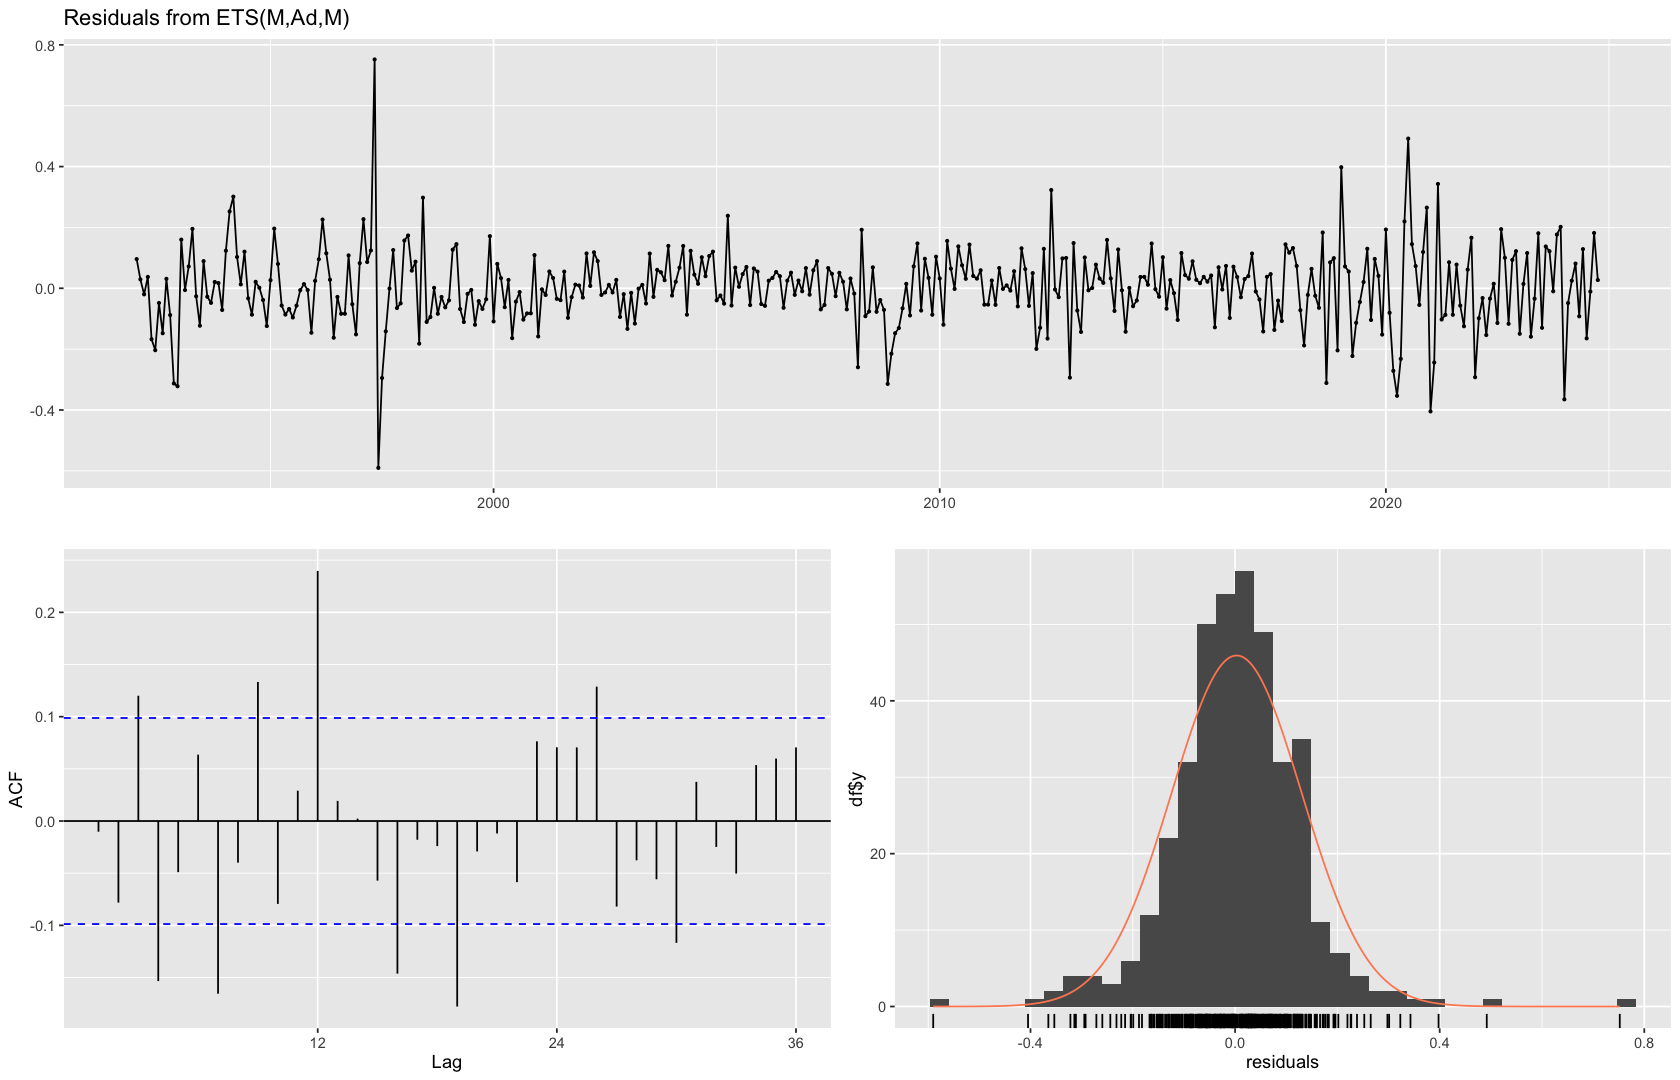

In [19]:
checkresiduals(ets_model)

### compare raw data (black) vs. fitted model (red)

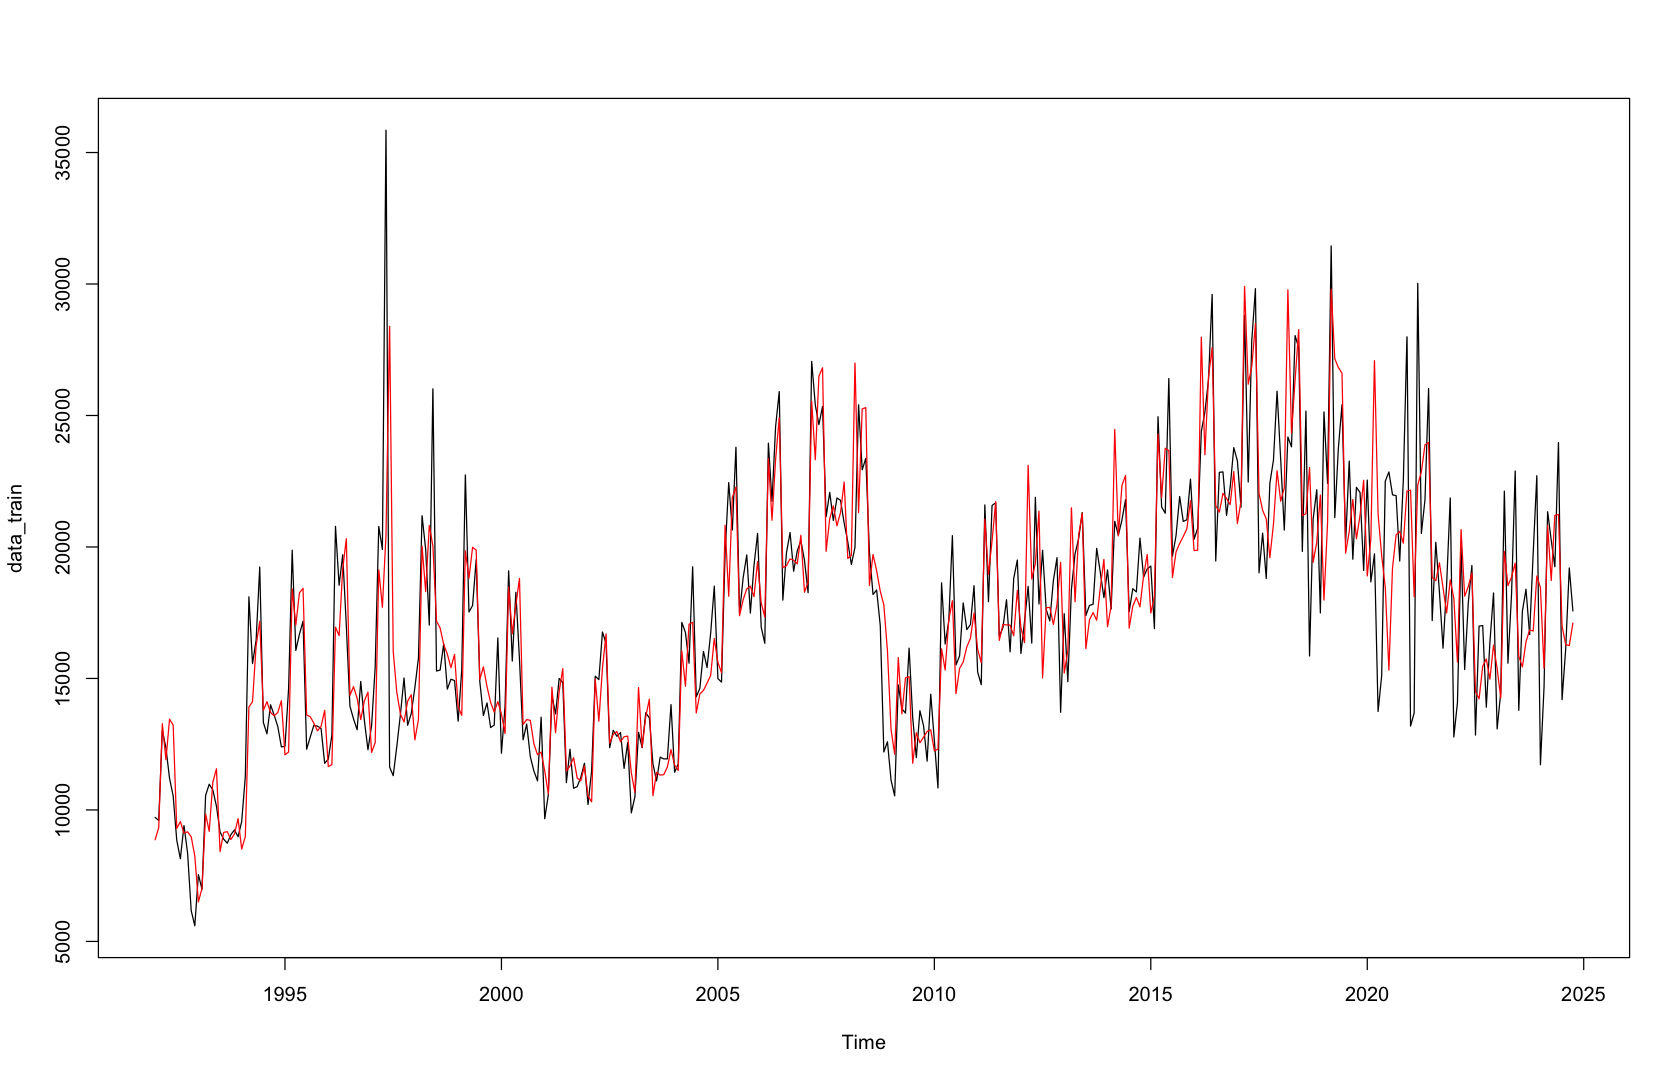

In [20]:
plot(data_train, type = "l")
lines(ets_model$fitted, col = "red")

### forecast fitted ETS model

In [21]:
forecast_ets <- forecast(ets_model, h = n - n_train) 

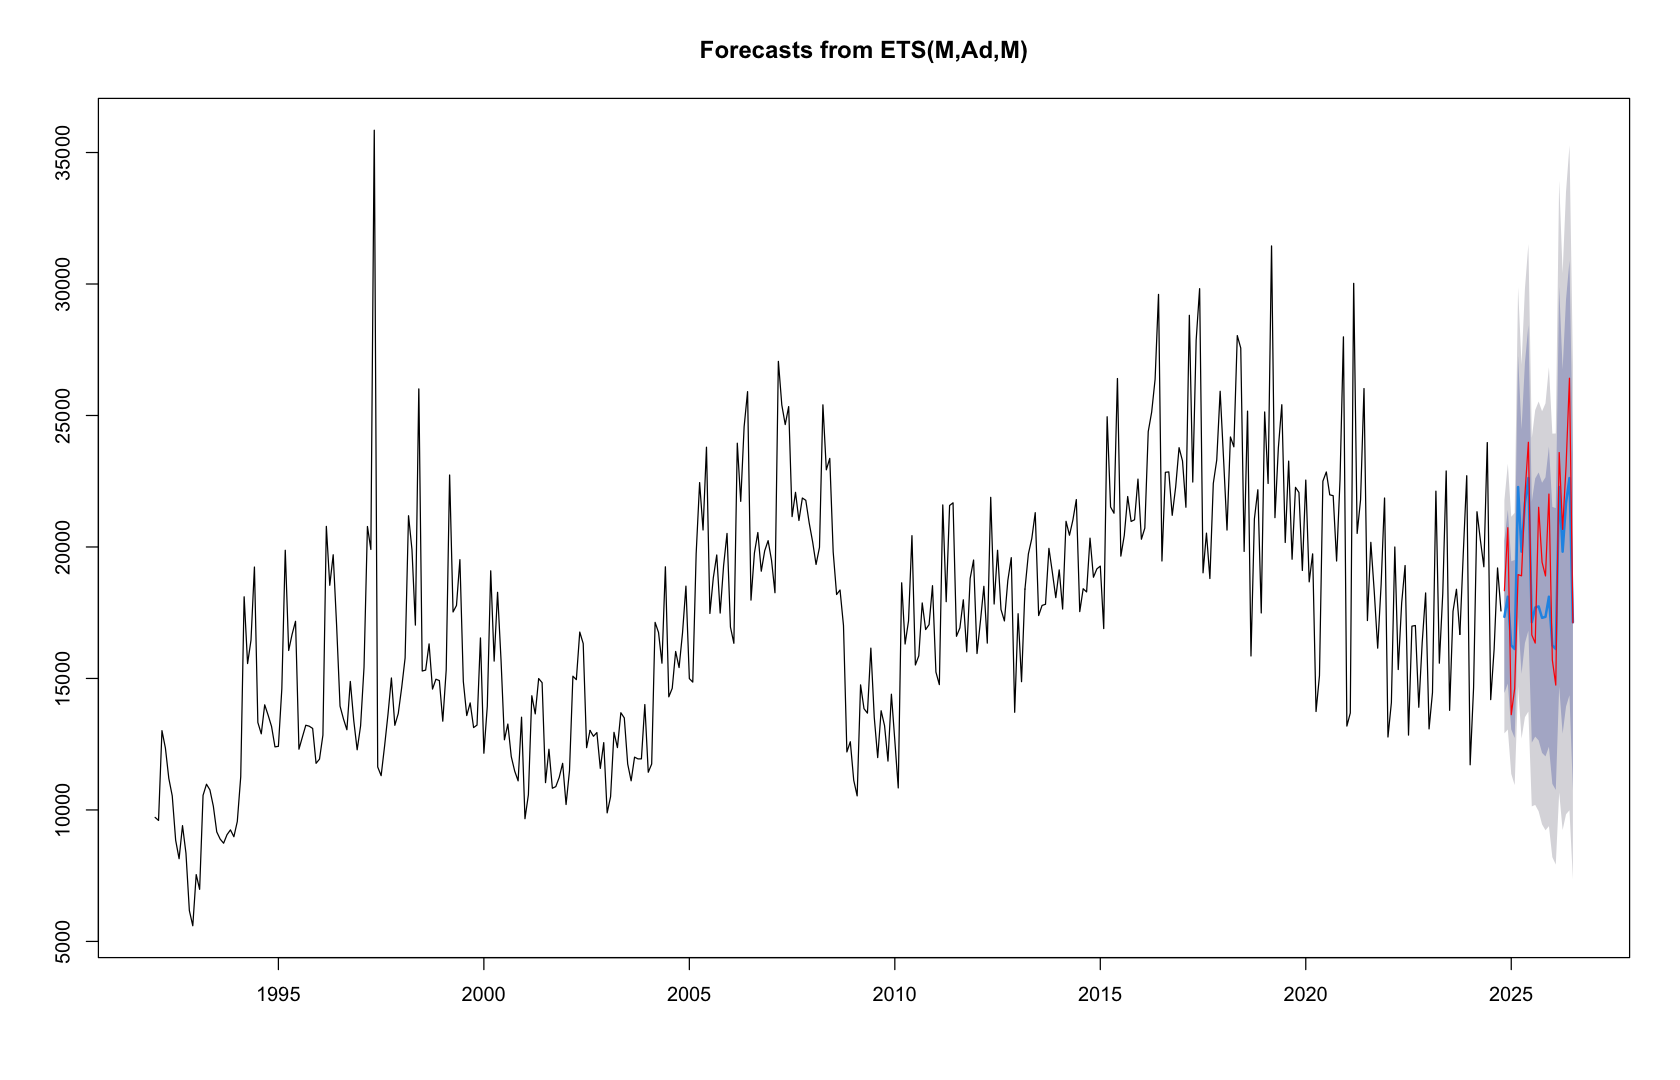

In [22]:
plot(forecast_ets)
lines(data_test, col = 'red')

## Compare accuracies of STL-ARIMA vs. ETS models

In [23]:
accuracy(forecast_stl_arima, data_test)
accuracy(forecast_ets, data_test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,54.55138,2049.710,1365.242,-0.6379949,8.162615,0.5325378,0.002263787,NA
Test set,772.82264,2146.108,1736.563,2.9210829,8.773031,0.6773788,0.275587008,0.5027367


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-9.445477,2433.503,1640.136,-1.488801,9.736166,0.6397655,-0.09286148,NA
Test set,561.673920,2073.702,1721.674,1.587396,8.849819,0.6715709,0.21369901,0.4972262


***

# Summary:
- ETS model outperforms the STL-ARIMA model by RMSE, MAE, MPE, MASE.
- An autocorrelation of residuals (~0.21) in the test set for both models, which indicates how the two models failed to explain patterns in the test data. Adjustment of the models is likely needed to increase performance.

***